# Google Stock Price Prediction using RNN

Simple RNN model for Google stock price prediction.

In [3]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

In [5]:
# Load Dataset

df = pd.read_csv("google_stock_prices.csv")

print(df.head())

       Date    Open    High     Low   Close      Volume
0  1/3/2012  325.25  332.83  324.97  663.59   7,380,500
1  1/4/2012  331.27  333.87  329.08  666.45   5,749,400
2  1/5/2012  329.83  330.75  326.89  657.21   6,590,300
3  1/6/2012  328.34  328.77  323.68  648.24   5,405,900
4  1/9/2012  322.04  322.29  309.46  620.76  11,688,800


In [7]:
# Select Close Price
df['Close'] = df['Close'].str.replace(',', '').astype(float)
data = df[['Close']].values

# Scale Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.23757287]
 [0.24151427]
 [0.22878051]
 [0.21641884]
 [0.1785483 ]]


In [8]:
# Create Time Series Data

x_train = []
y_train = []

time_step = 10

for i in range(time_step, len(scaled_data)):
    x_train.append(scaled_data[i-time_step:i, 0])
    y_train.append(scaled_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print("Before Reshape:", x_train.shape)

Before Reshape: (1248, 10)


In [9]:
# Reshape Data for RNN

x_train = np.reshape(
    x_train,
    (x_train.shape[0], x_train.shape[1], 1)
)

print("After Reshape:", x_train.shape)

After Reshape: (1248, 10, 1)


In [10]:
# Build RNN Model

model = Sequential()

model.add(
    SimpleRNN(
        units=50,
        activation='tanh',
        input_shape=(x_train.shape[1], 1)
    )
)

model.add(Dense(1))

model.summary()

C:\Users\Arclooks\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile Model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [12]:
# Train Model

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0064 - mae: 0.0497
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - mae: 0.0253
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - mae: 0.0189    
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0167  
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - mae: 0.0198
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - mae: 0.0197   
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - mae: 0.0171
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - mae: 0.0200   
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - mae: 0.0168
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0154    
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - mae: 0.0171
Epoch 12/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0168    
Epoch 13/20
39/39 ━━━━━━━━━━━

In [13]:
# Predict Prices

predicted = model.predict(x_train)

predicted = scaler.inverse_transform(predicted)

real = scaler.inverse_transform(
    y_train.reshape(-1,1)
)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


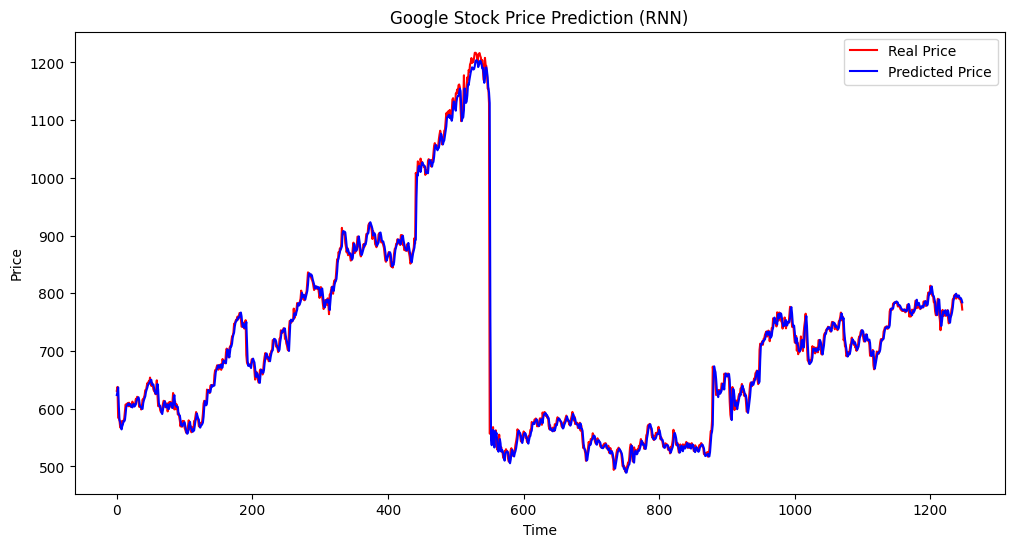

In [14]:
# Plot Results

plt.figure(figsize=(12,6))

plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Conclusion
The RNN model predicts Google stock prices using previous time-step values.